<a href="https://colab.research.google.com/github/alissongurgel8/Impact/blob/main/Impact5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo de momentum


Baixando dados do Yahoo Finance...


[*********************100%***********************]  15 of 15 completed



=== RESULTADOS AJUSTADOS (COM CUSTOS E IR) ===
Modelo Momentum (Top 5): CAGR = 26.76% | Vol = 25.35% | Sharpe = 0.63 | Max DD = -41.73%
Ibovespa (^BVSP):             CAGR = 14.43% | Vol = 21.58% | Sharpe = 0.17 | Max DD = -37.03%


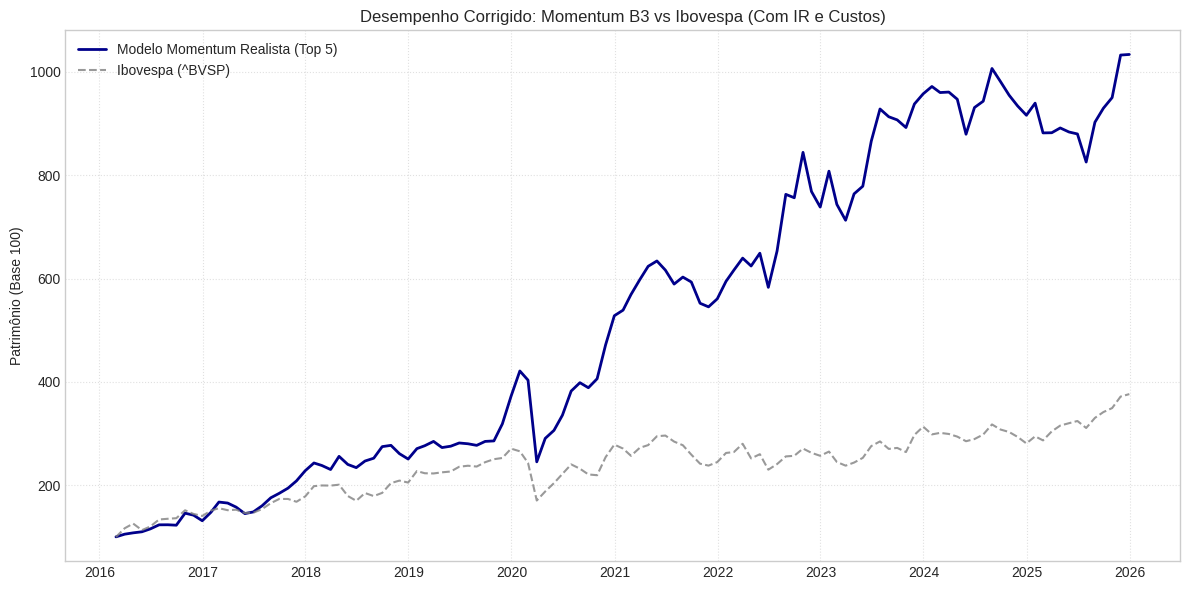

In [9]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# ==========================================
# 1. PARÂMETROS DA ESTRATÉGIA
# ==========================================
TICKERS = [
    'VALE3.SA', 'PETR4.SA', 'ITUB4.SA', 'BBDC4.SA', 'ABEV3.SA',
    'WEGE3.SA', 'RENT3.SA', 'BBAS3.SA', 'SUZB3.SA', 'EQTL3.SA',
    'PRIO3.SA', 'GGBR4.SA', 'RDOR3.SA', 'RAIL3.SA'
]
BENCHMARK = '^BVSP'
START_DATE = '2015-01-01'  # 1 ano a mais para cálculo da janela de 12M
END_DATE = '2026-01-01'

TOP_N = 5
LOOKBACK = 12
SKIP = 1
COST_PER_TRADE = 0.0015  # 0.15% para emolumentos + slippage por operação
TAX_RATE = 0.15          # 15% de IR sobre lucro de capital realizado
SELIC_ANUAL = 0.1075     # Risk-free / CDI estimado para dias de Caixa (10.75%)

# ==========================================
# 2. DOWNLOAD E PREPARAÇÃO DOS DADOS
# ==========================================
print("Baixando dados do Yahoo Finance...")
data_daily = yf.download(TICKERS + [BENCHMARK], start=START_DATE, end=END_DATE, auto_adjust=False)['Adj Close']

# Dados diários separados
df_acoes = data_daily[TICKERS].dropna(how='all')
df_bench = data_daily[BENCHMARK].dropna()

# Amostragem mensal (último dia útil do mês)
df_monthly = df_acoes.resample('ME').last()

# Retornos mensais reais para o período de execução
returns_monthly = df_monthly.pct_change()

# ==========================================
# 3. CÁLCULO DO MOMENTUM (12-1M)
# ==========================================
# Momentum = Preço(M-1) / Preço(M-12) - 1
momentum = df_monthly.shift(SKIP) / df_monthly.shift(LOOKBACK) - 1

# ==========================================
# 4. BACKTEST COM EXECUÇÃO EM T+1, CUSTOS E IR
# ==========================================
portfolio_history = []
dates = df_monthly.index[LOOKBACK + SKIP:]

capital = 100.0
caixa_cdi_mensal = (1 + SELIC_ANUAL) ** (1/12) - 1

# Dicionários de controle de posições
prev_positions = {}  # ticker: preço_de_compra

for i, date in enumerate(dates):
    idx_loc = df_monthly.index.get_loc(date)

    # 1. Sinal calculado com base no fechamento do mês anterior
    mom_signal = momentum.iloc[idx_loc - 1]

    # Seleção Top N com momentum positivo
    valid_signals = mom_signal[mom_signal > 0].dropna()
    top_assets = valid_signals.nlargest(TOP_N).index.tolist()

    # 2. Execução e Retorno do Mês Atual
    ret_month = returns_monthly.loc[date]

    if len(top_assets) > 0:
        weight = 1.0 / len(top_assets)
        gross_return = sum(ret_month[asset] * weight for asset in top_assets)

        # --- CÁLCULO DE CUSTOS E IR ---
        turnover_cost = 0.0
        tax_cost = 0.0

        # Identificar compras e vendas para aplicar taxas
        current_positions = set(top_assets)
        previous_positions = set(prev_positions.keys())

        exited_assets = previous_positions - current_positions
        entered_assets = current_positions - previous_positions

        # Custo de corretagem/slippage proporcional ao rebalanceamento
        turnover_ratio = (len(exited_assets) + len(entered_assets)) / (2 * TOP_N)
        turnover_cost = turnover_ratio * COST_PER_TRADE

        # IR sobre papéis encerrados com lucro
        for asset in exited_assets:
            entry_price = prev_positions[asset]
            exit_price = df_monthly.loc[date, asset]
            asset_return = (exit_price / entry_price) - 1

            if asset_return > 0:
                # IR sobre a fatia referente ao ativo no patrimônio
                tax_cost += (asset_return * weight) * TAX_RATE

        # Atualiza histórico de preços de entrada para o próximo mês
        prev_positions = {asset: df_monthly.loc[date, asset] for asset in top_assets}

        # Retorno líquido final do mês
        net_return = gross_return - turnover_cost - tax_cost
    else:
        # Se nenhuma ação tem momentum positivo: 100% no CDI (Caixa)
        net_return = caixa_cdi_mensal
        prev_positions = {}

    capital *= (1 + net_return)
    portfolio_history.append({'Date': date, 'Capital': capital, 'Return': net_return})

# Dataframe do Modelo
df_res = pd.DataFrame(portfolio_history).set_index('Date')

# ==========================================
# 5. BENCHMARK (IBOVESPA)
# ==========================================
bench_monthly = df_bench.resample('ME').last().loc[dates[0]:dates[-1]]
bench_returns = bench_monthly.pct_change().fillna(0)
bench_capital = 100.0 * (1 + bench_returns).cumprod()

# ==========================================
# 6. MÉTRICAS DE DESEMPENHO
# ==========================================
def get_metrics(cap_series, ret_series):
    years = (cap_series.index[-1] - cap_series.index[0]).days / 365.25
    cagr = (cap_series.iloc[-1] / cap_series.iloc[0]) ** (1 / years) - 1
    vol = ret_series.std() * np.sqrt(12)
    sharpe = (cagr - SELIC_ANUAL) / vol if vol != 0 else 0

    cum_max = cap_series.cummax()
    drawdown = (cap_series - cum_max) / cum_max
    max_dd = drawdown.min()

    return cagr, vol, sharpe, max_dd

cagr_m, vol_m, sharpe_m, dd_m = get_metrics(df_res['Capital'], df_res['Return'])
cagr_b, vol_b, sharpe_b, dd_b = get_metrics(bench_capital, bench_returns)

print("\n=== RESULTADOS AJUSTADOS (COM CUSTOS E IR) ===")
print(f"Modelo Momentum (Top {TOP_N}): CAGR = {cagr_m:.2%} | Vol = {vol_m:.2%} | Sharpe = {sharpe_m:.2f} | Max DD = {dd_m:.2%}")
print(f"Ibovespa (^BVSP):             CAGR = {cagr_b:.2%} | Vol = {vol_b:.2%} | Sharpe = {sharpe_b:.2f} | Max DD = {dd_b:.2%}")

# ==========================================
# 7. GRÁFICO COMPARATIVO
# ==========================================
plt.figure(figsize=(12, 6))
plt.plot(df_res.index, df_res['Capital'], label=f'Modelo Momentum Realista (Top {TOP_N})', color='darkblue', linewidth=2)
plt.plot(bench_capital.index, bench_capital, label='Ibovespa (^BVSP)', color='gray', linestyle='--', alpha=0.8)
plt.title(f'Desempenho Corrigido: Momentum B3 vs Ibovespa (Com IR e Custos)')
plt.ylabel('Patrimônio (Base 100)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()